<h1>Train — ConvNeXt-Tiny</h1>

Trains and evaluates ConvNeXt-Tiny using the tuned hyperparameters from `ARCH_HYPERPARAMS["convnext_tiny"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["convnext_tiny"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ConvNeXt-Tiny: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ConvNeXt-Tiny: micro batch = 8, accumulation steps = 1 (effective batch size ≈ 8, tuned value = 8)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ConvNeXt-Tiny)
# ---------------------------------------------------------
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

model.avgpool = nn.AdaptiveMaxPool2d(1)

in_f = model.classifier[2].in_features
model.classifier[2] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
# criterion = FocalLoss(weight=class_weights_arch, gamma=2.0)  # parked for later -- see todo.txt

optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)

scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ConvNeXt-Tiny] Epoch   1/100 | LR: 6.78e-05 | train loss 0.9710 acc 0.612 | val loss 0.8749 acc 0.594 *


[ConvNeXt-Tiny] Epoch   2/100 | LR: 6.78e-05 | train loss 0.7614 acc 0.746 | val loss 0.6007 acc 0.688 *


[ConvNeXt-Tiny] Epoch   3/100 | LR: 6.78e-05 | train loss 0.6535 acc 0.770 | val loss 0.4315 acc 0.794 *


[ConvNeXt-Tiny] Epoch   4/100 | LR: 6.78e-05 | train loss 0.5665 acc 0.791 | val loss 0.5890 acc 0.718


[ConvNeXt-Tiny] Epoch   5/100 | LR: 6.78e-05 | train loss 0.5006 acc 0.795 | val loss 0.3321 acc 0.859 *


...

[ConvNeXt-Tiny] Epoch  14/100 | LR: 6.78e-05 | train loss 0.2433 acc 0.915 | val loss 0.5641 acc 0.788


[ConvNeXt-Tiny] Epoch  15/100 | LR: 6.78e-05 | train loss 0.1771 acc 0.946 | val loss 0.6060 acc 0.818


[ConvNeXt-Tiny] Epoch  16/100 | LR: 6.78e-05 | train loss 0.1887 acc 0.942 | val loss 0.5834 acc 0.800


[ConvNeXt-Tiny] Epoch  17/100 | LR: 6.78e-05 | train loss 0.1574 acc 0.958 | val loss 0.5791 acc 0.788


[ConvNeXt-Tiny] Epoch  18/100 | LR: 6.78e-05 | train loss 0.0873 acc 0.975 | val loss 0.5533 acc 0.812

[ConvNeXt-Tiny] No val loss improvement for 10 epochs — stopping early at epoch 18.

[ConvNeXt-Tiny] Restored best checkpoint (val loss = 0.3274)


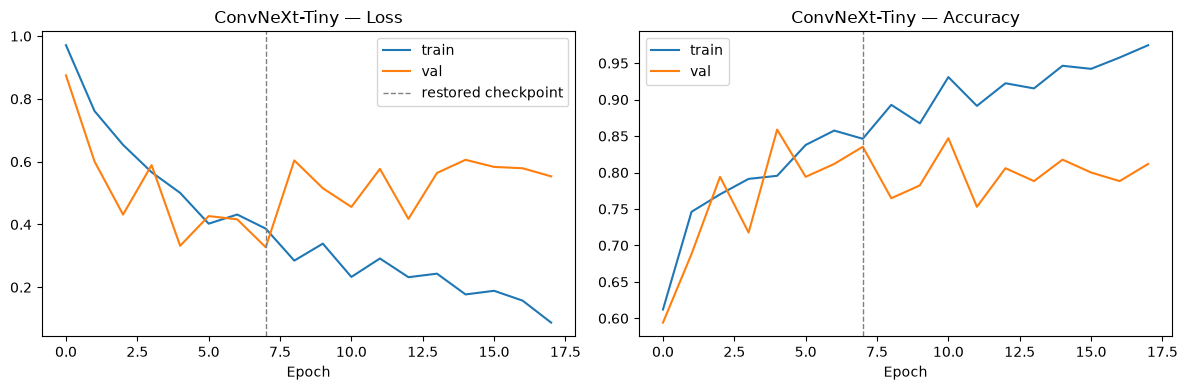

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ConvNeXt-Tiny", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ConvNeXt-Tiny")

## Evaluate on the test set

[ConvNeXt-Tiny] Test accuracy: 0.705


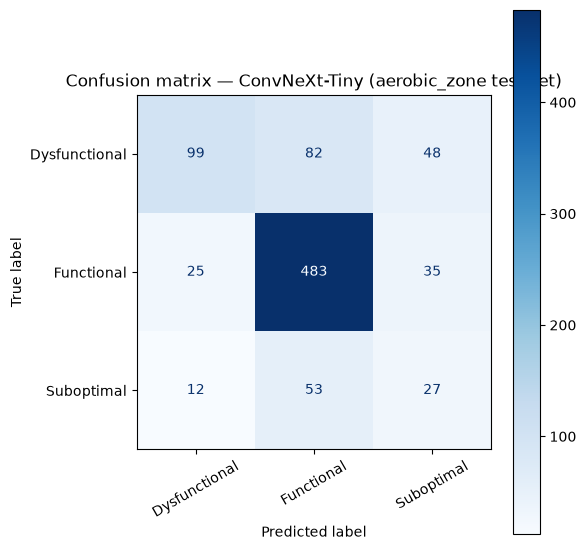

               precision    recall  f1-score   support

Dysfunctional      0.728     0.432     0.542       229
   Functional      0.782     0.890     0.832       543
   Suboptimal      0.245     0.293     0.267        92

     accuracy                          0.705       864
    macro avg      0.585     0.538     0.547       864
 weighted avg      0.710     0.705     0.695       864



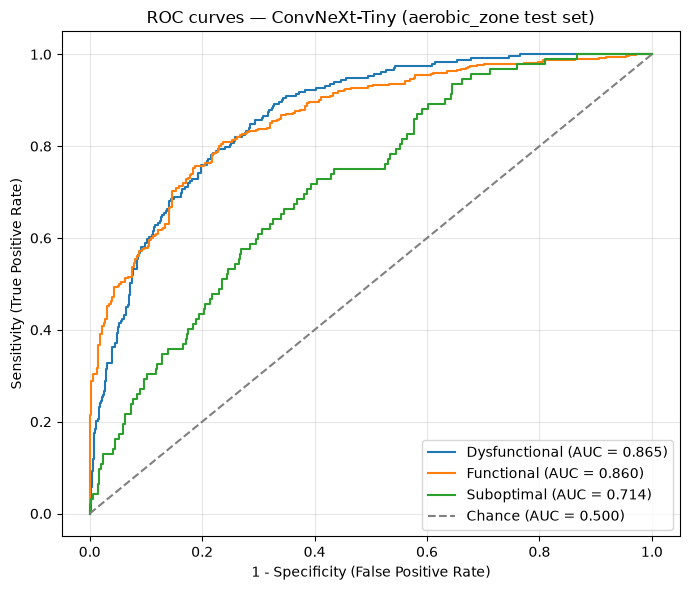

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.865
  Functional     : 0.860
  Suboptimal     : 0.714

Mean AUC (over 3/3 classes with test examples): 0.813


(np.float64(0.7048611111111112),
 {'Dysfunctional': 0.8645806828731561,
  'Functional': 0.8598016098403356,
  'Suboptimal': 0.714195201621987})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ConvNeXt-Tiny", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("ConvNeXt-Tiny", "convnext_tiny")

Saved results to ../results/aerobic_zone_aug/results_aerobic_zone_convnext_tiny_Waterval.pkl
Saved model weights to ../models/aerobic_zone_convnext_tiny_cnn.pt
